# Encoding
- 범주형 데이터(주로 문자열 데이터)를 숫자로 변환하는 기법
    - Label Encoding
    - Ont-Hot Encoding

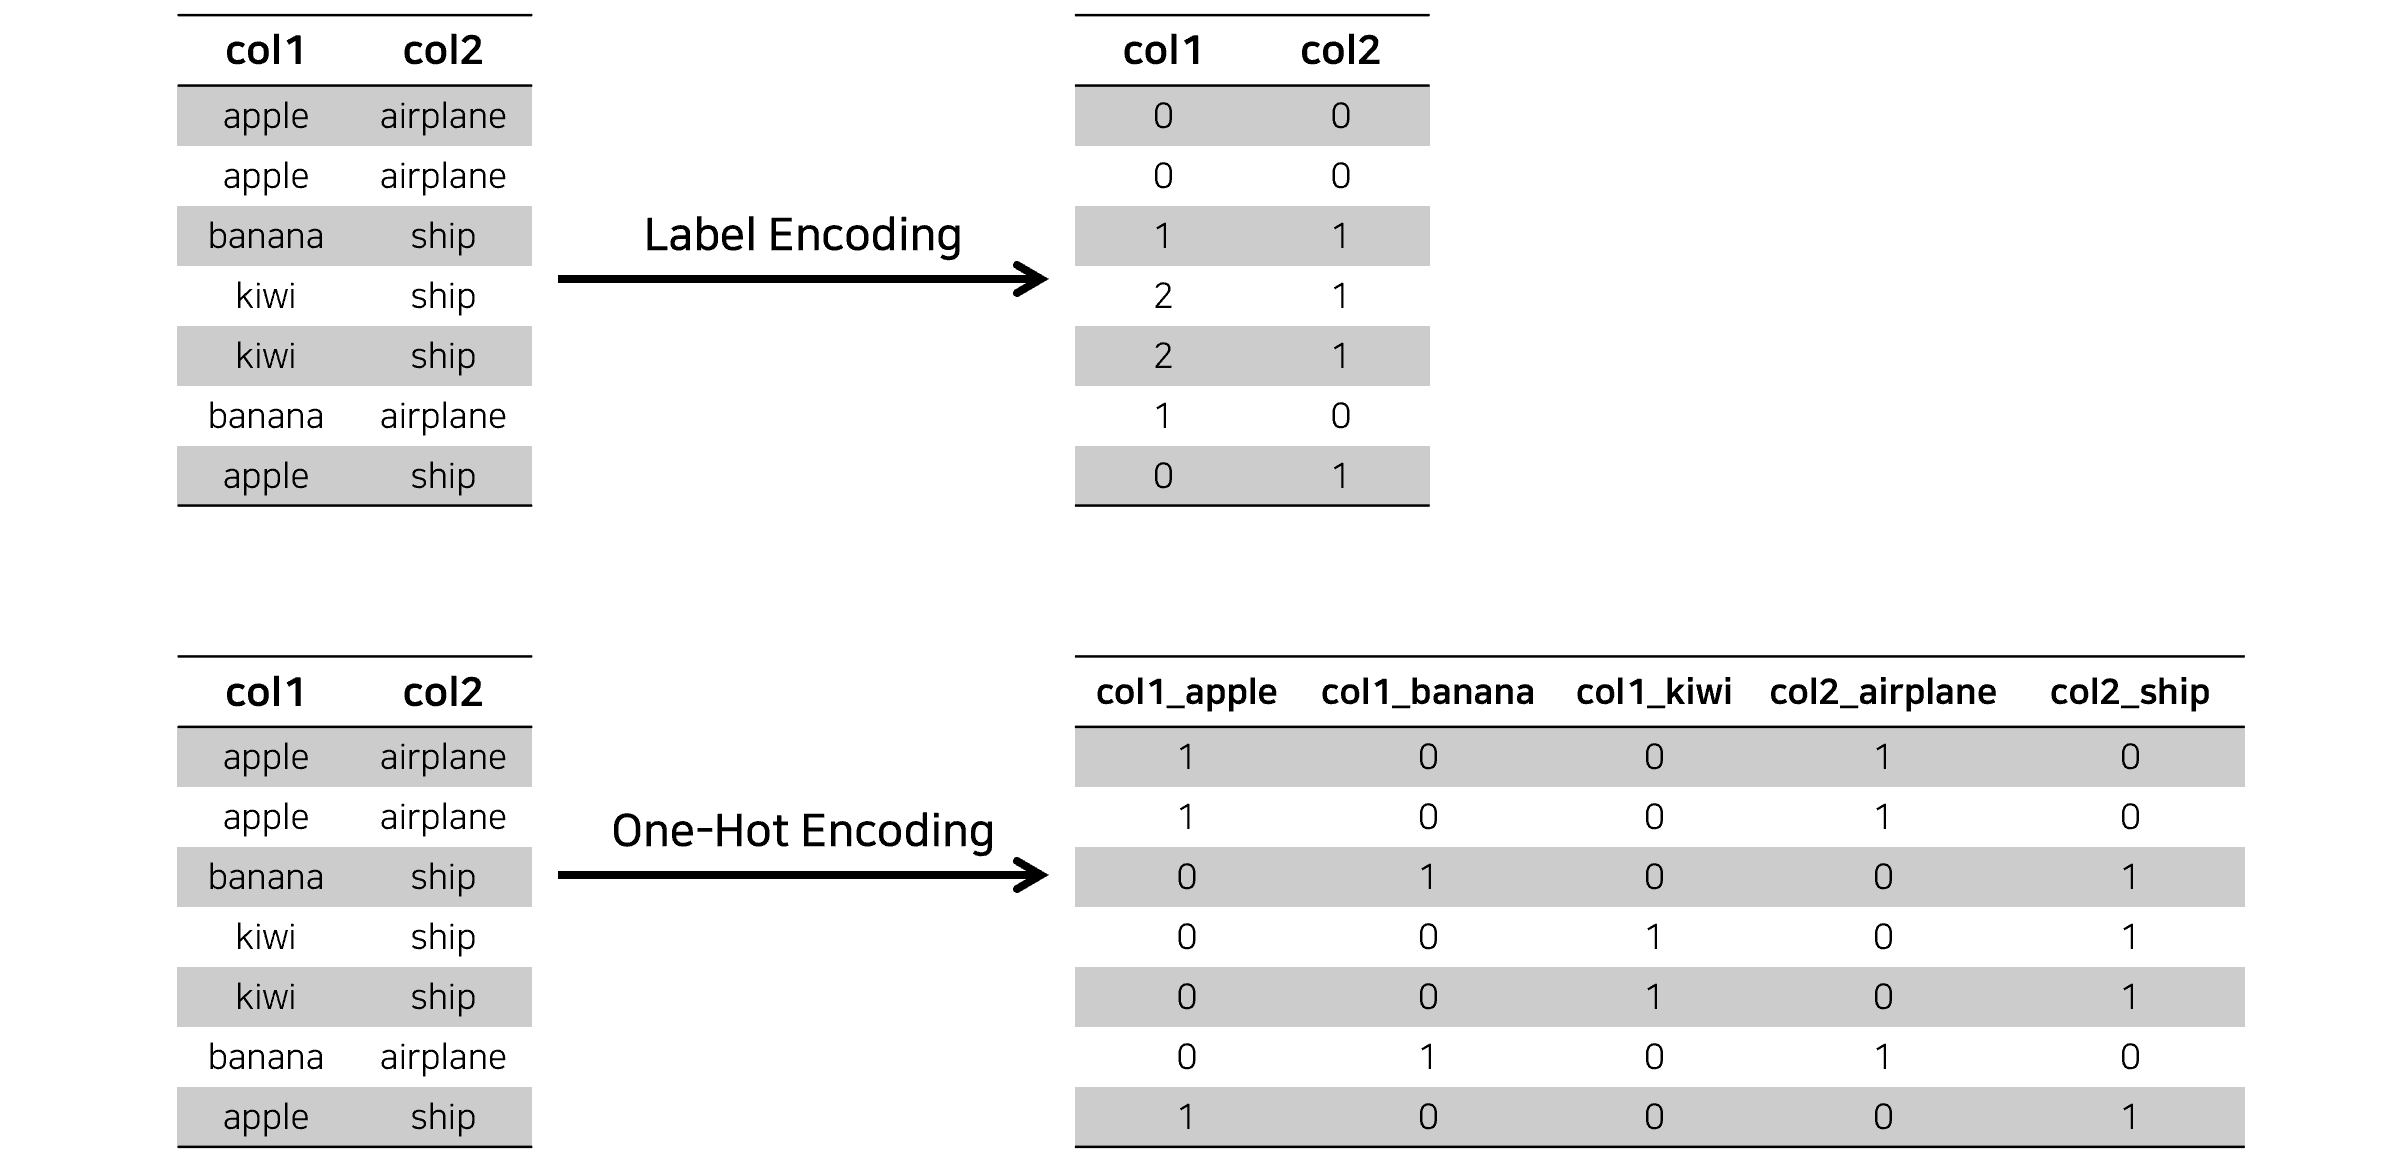

<br/>
<br/>

In [1]:
# (코드 실행)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'NanumGothic' # NanumGothic
plt.rcParams['axes.unicode_minus'] = False

<br/>
<br/>

### LabelEncoder
```python
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder() # 인코더 생성
encoder.fit(df[컬럼명]) # 규칙 생성
df[컬럼명] = encoder.transform(df[컬럼명]) # 생성된 규칙에 따라 인코딩
```

In [11]:
# (코드 실행) 데이터 생성
df = pd.DataFrame({
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red', np.nan, 'Green', 'Red'],
    'Size':  ['S', 'M', 'L', np.nan, 'XL', 'M', 'L', 'S'],
    'Class': ['Apple', 'Pear', 'Orange', 'Apple', 'Banana', 'Orange', np.nan, 'Pear']
})
df.style.highlight_null(color='yellow')

,Color,Size,Class
0,Red,S,Apple
1,Green,M,Pear
2,Blue,L,Orange
3,Green,nan,Apple
4,Red,XL,Banana
5,nan,M,Orange
6,Green,L,nan
7,Red,S,Pear


In [3]:
# Color 열에 라벨인코더 적용


,Color,Size,Class
0,2,S,Apple
1,1,M,Pear
2,0,L,Orange
3,1,NaN,Apple
4,2,XL,Banana
5,3,M,Orange
6,1,L,NaN
7,2,S,Pear


In [4]:
# (참고) fit()에서 생성된 규칙
encoder.classes_

array(['Blue', 'Green', 'Red', nan], dtype=object)

In [5]:
# Size, Class 열에 라벨인코더 적용


,Color,Size,Class
0,2,2,0
1,1,1,3
2,0,0,2
3,1,4,0
4,2,3,1
5,3,1,2
6,1,0,4
7,2,2,3


<br/>
<br/>

### One-Hot Encoder
```python
pd.get_dummies(columns = [컬럼명1, 컬럼명2, ...]) # 지정한 열을 원핫 인코딩
```

In [6]:
# (코드 실행) 데이터 생성
df = pd.DataFrame({
    '고객구분': ['신규', '재방문', 'VIP', '신규', '재방문', 'VIP', '신규', np.nan],
    '결제수단': ['신용카드', '페이팔', '신용카드', '은행이체', '신용카드', np.nan, '페이팔', '은행이체'],
    '구매금액': [120.50, 75.00, 200.00, 45.30, 130.00, 350.75, np.nan, 80.20]
})
df.style.highlight_null(color='yellow')

,고객구분,결제수단,구매금액
0,신규,신용카드,120.500000
1,재방문,페이팔,75.000000
2,VIP,신용카드,200.000000
3,신규,은행이체,45.300000
4,재방문,신용카드,130.000000
5,VIP,nan,350.750000
6,신규,페이팔,nan
7,nan,은행이체,80.200000


In [7]:
# 문자열 타입(범주형) 열 원핫인코딩


,구매금액,고객구분_VIP,고객구분_신규,고객구분_재방문,결제수단_신용카드,결제수단_은행이체,결제수단_페이팔
0,120.50,False,True,False,True,False,False
1,75.00,False,False,True,False,False,True
2,200.00,True,False,False,True,False,False
3,45.30,False,True,False,False,True,False
4,130.00,False,False,True,True,False,False
5,350.75,True,False,False,False,False,False
6,NaN,False,True,False,False,False,True
7,80.20,False,False,False,False,True,False


In [8]:
# 문자열 타입(범주형) 열 원핫인코딩 - 정수


,구매금액,고객구분_VIP,고객구분_신규,고객구분_재방문,결제수단_신용카드,결제수단_은행이체,결제수단_페이팔
0,120.50,0,1,0,1,0,0
1,75.00,0,0,1,0,0,1
2,200.00,1,0,0,1,0,0
3,45.30,0,1,0,0,1,0
4,130.00,0,0,1,1,0,0
5,350.75,1,0,0,0,0,0
6,NaN,0,1,0,0,0,1
7,80.20,0,0,0,0,1,0


In [9]:
# 문자열 타입(범주형) 열 원핫인코딩 - 결측치 포함


,구매금액,고객구분_VIP,고객구분_신규,고객구분_재방문,고객구분_nan,결제수단_신용카드,결제수단_은행이체,결제수단_페이팔,결제수단_nan
0,120.50,0,1,0,0,1,0,0,0
1,75.00,0,0,1,0,0,0,1,0
2,200.00,1,0,0,0,1,0,0,0
3,45.30,0,1,0,0,0,1,0,0
4,130.00,0,0,1,0,1,0,0,0
5,350.75,1,0,0,0,0,0,0,1
6,NaN,0,1,0,0,0,0,1,0
7,80.20,0,0,0,1,0,1,0,0


In [10]:
# 결제수단 열 원핫인코딩


,고객구분,구매금액,결제수단_신용카드,결제수단_은행이체,결제수단_페이팔,결제수단_nan
0,신규,120.50,1,0,0,0
1,재방문,75.00,0,0,1,0
2,VIP,200.00,1,0,0,0
3,신규,45.30,0,1,0,0
4,재방문,130.00,1,0,0,0
5,VIP,350.75,0,0,0,1
6,신규,NaN,0,0,1,0
7,NaN,80.20,0,1,0,0
